# Homework 4
## Part A
### Prompt
"fit the CAPM model r_i − r_f = α_i + β_i (r_M − r_f) + ε for
each of the 10 stocks, and report whether CAPM “holds” for each (i.e., test α_i = 0). Paste
prompts, code, output" + files:_sp500ret_3mtcm.txt, m_logret_10stocks.txt
### Code

In [7]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# ---- Load data ----
stocks = pd.read_csv('m_logret_10stocks.txt', sep='\t')
stocks = stocks.dropna(how='all').reset_index(drop=True)

mkt = pd.read_csv('m_sp500ret_3mtcm.txt', sep=r'\t+', skiprows=2,
                   names=['Date', 'sp500', 'tcm3m'], engine='python')
mkt = mkt.dropna(how='all').reset_index(drop=True)

assert len(stocks) == len(mkt)
n = len(stocks)

# Convert annualized 3-month T-bill (%) to a monthly risk-free rate
rf_monthly = (mkt['tcm3m'].astype(float) / 100.0) / 12.0
mkt_excess = mkt['sp500'].astype(float) - rf_monthly

tickers = [c for c in stocks.columns if c != 'Date']

results = []
for tic in tickers:
    y = stocks[tic].astype(float) - rf_monthly          # stock excess return
    X = sm.add_constant(mkt_excess.values)               # market excess return
    model = sm.OLS(y.values, X).fit()

    results.append({
        'Ticker': tic,
        'Alpha': model.params[0], 'Alpha_t': model.tvalues[0], 'Alpha_p': model.pvalues[0],
        'Beta': model.params[1],  'Beta_t': model.tvalues[1],
        'R2': model.rsquared,
        'CAPM_holds(alpha=0 @5%)': 'Yes' if model.pvalues[0] > 0.05 else 'No'
    })

res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))

Ticker     Alpha   Alpha_t  Alpha_p     Beta    Beta_t       R2 CAPM_holds(alpha=0 @5%)
  AAPL  0.003847  0.761359 0.447607 1.384640  4.894173 0.134603                     Yes
  ADBE  0.004658  0.952851 0.342159 1.531350  5.595026 0.168935                     Yes
   ADP  0.000807  0.428918 0.668582 0.847677  8.047209 0.296024                     Yes
   AMD -0.000619 -0.104606 0.916825 2.323827  7.018503 0.242347                     Yes
  DELL  0.008884  2.163663 0.032032 1.674992  7.286495 0.256373                      No
   GTW -0.005425 -0.964727 0.336194 2.232802  7.091627 0.246174                     Yes
    HP  0.001900  0.521304 0.602904 0.875234  4.288303 0.106674                     Yes
   IBM  0.002626  1.094916 0.275263 1.347923 10.039950 0.395606                     Yes
  MSFT  0.004256  1.453327 0.148168 1.458539  8.897003 0.339500                     Yes
  ORCL  0.003910  0.880855 0.379769 1.567604  6.307056 0.205280                     Yes


## Part B
### R Code Needed

In [8]:
# cov_value <- cov(r_ADP_excess, r_M_excess)  
# var_value <- var(r_M_excess)                  

# cov_value
# var_value

### Output


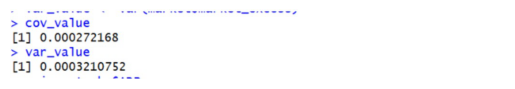

In [9]:
from PIL import Image
import matplotlib.pyplot as plt
img = Image.open(r"C:\Users\sromerod3\OneDrive\Documents\SEOUL 4803\r code part b hw 4.jpg")
plt.imshow(img)
plt.axis("off")
plt.show()


# Handcalculation


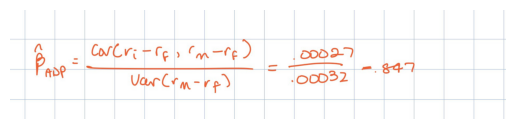

In [10]:
from PIL import Image
import matplotlib.pyplot as plt
img = Image.open(r"C:\Users\sromerod3\OneDrive\Documents\SEOUL 4803\Hw 4 part b.jpg")
plt.imshow(img)
plt.axis("off")
plt.show()

## Part C
1st error is the AI declaring that t-statistic of 0.4 is statistically significant. In fact the t-stat is actually nowhere near siginificant as it is <2.  
2nd error is that a large t-statistic within alpha means that CAPM holds. The AI has the opposite understanding as actually a large t on alpha is key to reject a CAPM

## Part D

Beta is about 0.85 means it is defensive, meaning it moves less than the market on average. Basically meaning that when the market moves 1%, ADP only moves .85%, so its a bit calmer. This could be helpful for an investor that wants to enter the market with less volatility.

If CAPM were rejected for a stock, this would mean it had an alpha not equal to 0. That means the stock earns a return that simple market risk cant exactly explain.

Overall, the assumption Id worry about the most is about error terms and their distribution over time. Looking at the stock volatility, it tends to cluster from calm to turbulent, so constant variance assumption can become shaky. I would check this by looking at the residual plots to see if there is a clear pattern or changing spread.